# NEGF Si Device Simulation Results

In [1]:
import numpy as np
import torch
import ase
import matplotlib.pyplot as plt

In [2]:
import pickle as pkl
import os

SIMULATION_RESULTS_DIR = './finalized_data/45_block_device/'
DATA_DIR = './finalized_data/'

result_files = list(sorted(os.listdir(SIMULATION_RESULTS_DIR)))
print(result_files)

['ii_avalanche_v-10.0_d10.pkl', 'ii_avalanche_v-5.0_d10.pkl', 'ii_avalanche_v0.0_d10.pkl']


## Calculation setup

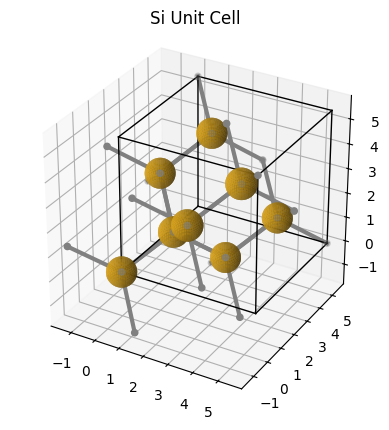

Length: 244.35
Smoothing length: 38.01


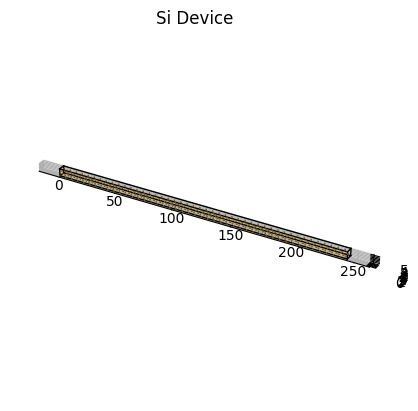

In [3]:
from pyquinn.types import AtomGraph
from ase.build import bulk

# plot silicon unit cell (built from ASE)
si_cubic_graph = AtomGraph.from_ase(bulk('Si', 'diamond', cubic=True))
fig = plt.figure()
fig = si_cubic_graph.plot(atom_resolution=64, fig=fig, show=False)
plt.title('Si Unit Cell')
plt.show()

si_block = si_cubic_graph.supercell([1,1,1])

device_blocks = 45
smoothing_blocks = 7


# build left lead (pristine):
lead_1 = si_block.copy()
lead_1.positions -= 1*si_block.unit_cell[0]
lead_1.periodic = (True, True, True)

# build right lead (pristine):
lead_2 = si_block.copy()
lead_2.positions += device_blocks*si_block.unit_cell[0]
lead_2.periodic = (True, True, True)

# build device region
#  (Optional: add random vacancy defects inside device)

n_removals = 0 # number of sites to remove

device = si_block.copy().supercell([device_blocks,1,1])
device.periodic = (False, True, True)

fig = plt.figure()
fig = device.plot(hide_bonds=True, fig=fig, show=False)
plt.title('Si Device')
fig.show()

# clear device unit cell:
device_length = float(device.unit_cell[0,0])

print('Length:', device_length)
device.unit_cell[0] = 0.0
smoothing_length = float(si_block.unit_cell[0,0]*smoothing_blocks)
print('Smoothing length:', smoothing_length)


/ion/home/burdinec/git/pyquinn/src/pyquinn/torch/util.py:152: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(


E_gap: [1.5361247]


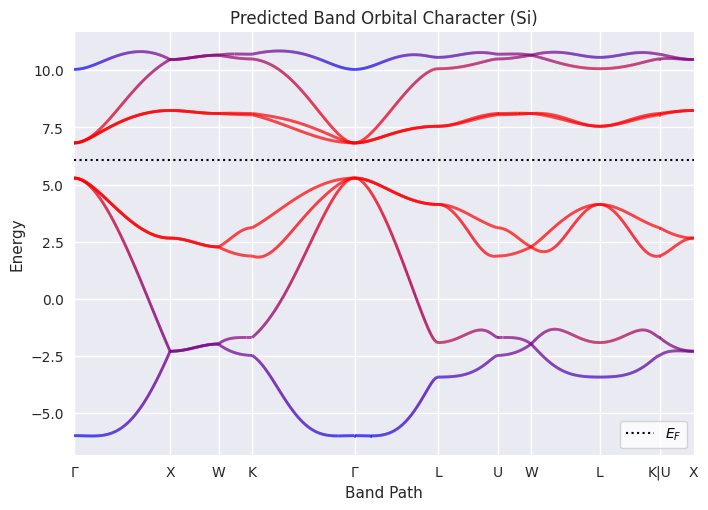

In [4]:
import matplotlib.pyplot as plt

si_graph = AtomGraph.load(os.path.join(DATA_DIR, 'mp-149_si_graph.pkl'))
torch_model = torch.load('si_3g_conduction_statedict.pt', weights_only=False)

torch_graph = si_graph.compile(
    backend='torch', 
    cutoffs={'Si': 4.0},
    device=torch.get_default_device()
)

torch_k_pts = torch_graph.band_path()
torch_pred_bands = torch_model.predict(torch_graph, k_pts=torch_k_pts)
torch_pred_bands.save(os.path.join(DATA_DIR, 'mp-149_si_bandpath.pkl'))

# Obtain a BandStructure object from the TorchBandStructure object
si_pred_bands = torch_pred_bands.extract()

# compute fermi energy
E_fermi = si_pred_bands.idos_level(
    n=8 - 1e-5,   # 8 electrons per unit cell 
                  # (minus small number to put E_f at bottom)
    band_mult=2,  # spin paired,
    sigma=1e-5,   # very little smearing,
    max_evals=100
)

E_gap = si_pred_bands.band_gap(
    energy=E_fermi + 0.5,
)
print('E_gap:', E_gap)

# extract s and p band orbital projections
s_projs = si_pred_bands.projections[...,:1].sum((-2,-1))
p_projs = si_pred_bands.projections[...,1:4].sum((-2,-1))
orb_projs = np.stack([ s_projs, p_projs ], axis=-1)

# plot orbital character of bands:
fig = si_pred_bands.plot_band_path(
    atoms=si_graph,
    show=False,
    proj_color_map=['blue', 'red'],
    proj_color_weights=np.stack([ s_projs, p_projs ], axis=-1),
    proj_color_labels = ['S Bands', 'P Bands'],
)
plt.axhline(E_fermi + E_gap/2, color='k', linestyle=':', label=r'$E_F$')

#plt.ylim((-7.5, 12))
plt.title('Predicted Band Orbital Character (Si)')
plt.legend(loc='lower right')
plt.show()

In [5]:
T = 300             # [K]
k = 8.617333262e-5 # [eV / K]
kt = k*T # [eV]

L_device = torch.tensor(device_length)
a_device = si_block.unit_cell[0,0]
lambda_device = torch.tensor(smoothing_length)

# set the effective fermi level
fermi_level = torch.tensor(E_fermi + E_gap/2).squeeze()
conduction_band_edge = torch.tensor(E_fermi + E_gap).squeeze()

# log_N_p = torch.log(torch.tensor(2.5))\
#     + torch.log(torch.tensor(10))*18 # 2.5e18 [cm^{-3}]
# log_N_n = torch.log(torch.tensor(4.0))\
#     + torch.log(torch.tensor(10))*18 # 4.0e18 [cm^{-3}]
# log_n_i = torch.log(torch.tensor(2.0))\
#     + torch.log(torch.tensor(10))*16 # 2.0e16 [cm^{-3}]

log_N_p = torch.log(torch.tensor(2.5e18))
log_N_n = torch.log(torch.tensor(4.0e18))
log_n_i = torch.log(torch.tensor(2.0e16))

# recommended i ~ 200 nm = 2,000 A 
# (for testing, we'll make it much smaller)

# V_bi = (kT/q) log( N_a N_d / n_i^2 )

dE_p = kt*(log_N_p - log_n_i)
dE_n = -kt*(log_N_n - log_n_i)


# SET MAX BIAS:
V_bias_max = -1.5


def U_device(x, V=0):
    x = x[:, 0]

    U_left  = dE_p - V / 2
    U_right = dE_n + V / 2

    x_L = 0
    x_R = L_device
    lam = lambda_device

    # Require 0 < lam < x_R - x_L
    F = (U_right - U_left) / (x_R - x_L - lam)

    U_left_flat = torch.full_like(x, U_left)
    U_right_flat = torch.full_like(x, U_right)

    # left smoothing region: x_L < x < x_L + lam
    U_left_smooth = U_left + F / (2 * lam) * (x - x_L)**2

    # central linear region: x_L + lam <= x <= x_R - lam
    U_linear = U_left + F * (x - x_L - lam / 2)

    # right smoothing region: x_R - lam < x < x_R
    U_right_smooth = U_right - F / (2 * lam) * (x_R - x)**2

    return torch.where(
        x <= x_L,
        U_left_flat,
        torch.where(
            x < x_L + lam,
            U_left_smooth,
            torch.where(
                x <= x_R - lam,
                U_linear,
                torch.where(
                    x < x_R,
                    U_right_smooth,
                    U_right_flat,
                ),
            ),
        ),
    )

## Load NEGF Simulation Results

In [6]:
result_dicts = []
for file in result_files:
    with open(os.path.join(SIMULATION_RESULTS_DIR, file), 'rb') as f:
        result_dicts.append(pkl.load(f))

In [10]:
# validate result dictionaries match device parameters:
for result_dict in result_dicts:
    if max(result_dict['Sites'])+1 != len(device):
        result_device_size = result_dict['Blocks'].max()+1
        raise ValueError(f"Device size ({len(device)}) must be same as result device size ({result_device_size})")
else:
    print('[Result dictionary size matches simiulation parameters.]')

[Result dictionary size matches simiulation parameters.]


In [11]:
print('Result dictionary keys:')
print(list(result_dicts[0].keys()))

Result dictionary keys:
['E', 'D_device', 'Sites', 'Blocks', 'V_bias', 'N_mesh', 'DOS_mesh', 'X_mesh', 'E_mesh']


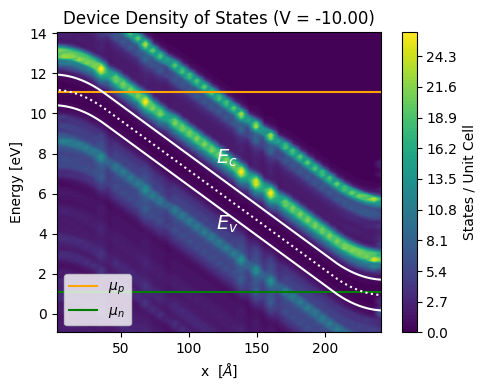

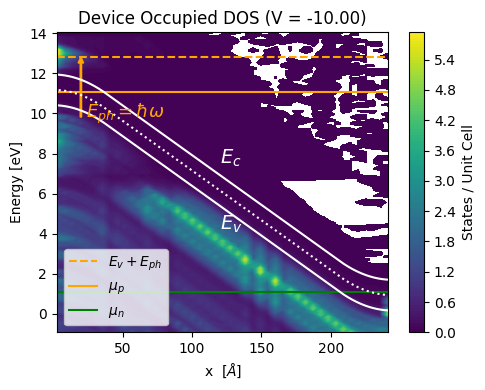

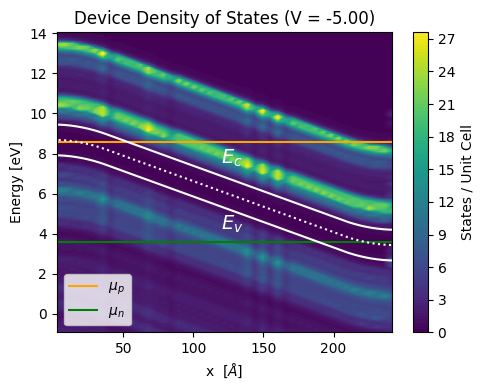

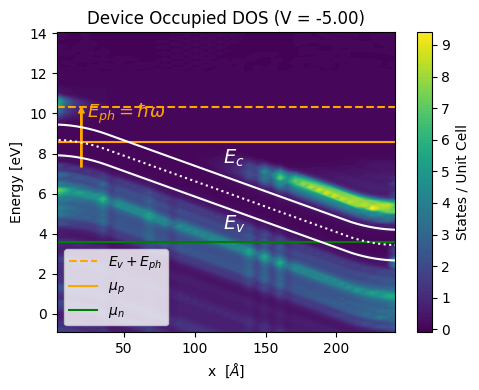

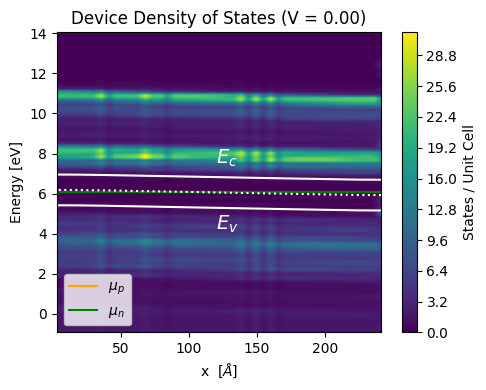

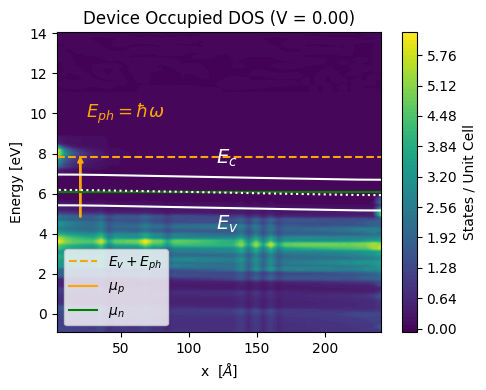

In [22]:
for result_dict in result_dicts:

    n_blocks = max(result_dict['Blocks'])+1
    x = (np.arange(n_blocks) + 0.5) * a_device
    X = np.array(result_dict['X_mesh'])
    E = np.array(result_dict['E_mesh'])
    V_bias = result_dict['V_bias']
    
    x_pts = torch.linspace(0, device_length, 1000)
    _x_pts = torch.zeros(1000,3)
    _x_pts[:,0] = torch.linspace(0, device_length, 1000)
    U_x_pts = U_device(_x_pts, V=V_bias).detach().numpy()
    x_pts = x_pts.detach().numpy()
    
    
    DOS = result_dict['DOS_mesh']
    N = result_dict['N_mesh']
    
    plt.figure(figsize=(5,4))
    plt.title(f'Device Density of States (V = {V_bias:.2f})')
    cm = plt.contourf(X, E, DOS, levels=100)
    cm.set_edgecolor("face")
    plt.axhline(fermi_level - V_bias/2, linestyle='-', color='orange', label=r'$\mu_p$')
    plt.axhline(fermi_level + V_bias/2, color='g', label=r'$\mu_{n}$')
    #plt.axhline(conduction_band_edge - V_idx/2 + 1.0, linestyle='--', color='orange', label=r'$\mu_{n} + E$')
    plt.annotate(r'$E_c$', xy=(120,7.5), color='w', fontsize=14)
    plt.annotate(r'$E_v$', xy=(120,4.2), color='w', fontsize=14)
    
    plt.colorbar(cm, label='States / Unit Cell')
    plt.plot(x_pts, fermi_level.item() + U_x_pts, 'w:')
    plt.plot(x_pts, fermi_level.item() + U_x_pts + E_gap/2, 'w')
    plt.plot(x_pts, fermi_level.item() + U_x_pts - E_gap/2, 'w')
    plt.xlim((x.min(),x.max()))
    plt.legend(loc='lower left')
    plt.ylabel('Energy [eV]')
    plt.xlabel(r'x  [$\AA$]')
    plt.tight_layout()    
    plt.show()
    
    
    plt.figure(figsize=(5,4))
    plt.title(f'Device Occupied DOS (V = {V_bias:.2f})')
    cm = plt.contourf(X, E, N, levels=100)
    cm.set_edgecolor("face")
    plt.axhline(conduction_band_edge - V_bias/2 + 1.0, linestyle='--', color='orange', label=r'$E_v + E_{ph}$')
    plt.axhline(fermi_level - V_bias/2, linestyle='-', color='orange', label=r'$\mu_{p}$')
    plt.axhline(fermi_level + V_bias/2, color='g', label=r'$\mu_{n}$')
    plt.annotate(r'$E_c$', xy=(120,7.5), color='w', fontsize=14)
    plt.annotate(r'$E_v$', xy=(120,4.2), color='w', fontsize=14)
    plt.arrow(20, conduction_band_edge - V_bias/2 - 2.0, dx=0, dy=2.7, color='orange', head_width=4.0, width=1, head_length=0.3)
    plt.annotate(r'$E_{ph} = \hbar\omega$', xy=(24,9.75), color='orange', fontsize=13)
    
    
    plt.colorbar(cm, label='States / Unit Cell')
    plt.plot(x_pts, fermi_level.item() + U_x_pts, 'w:')
    plt.plot(x_pts, fermi_level.item() + U_x_pts + E_gap/2, 'w')
    plt.plot(x_pts, fermi_level.item() + U_x_pts - E_gap/2, 'w')
    plt.xlim((x.min(),x.max()))
    plt.legend(loc='lower left')
    plt.ylabel('Energy [eV]')
    plt.xlabel(r'x  [$\AA$]')
    plt.tight_layout()
    plt.show()